# Module 5 - Class 4: t-SNE and UMAP Visualization

**Dataset:** Mall Customer Segmentation  
**Objective:** Compare PCA, t-SNE, and UMAP for 2D visualization of customer clusters.

### What you will learn
- PCA limitations for non-linear structure
- t-SNE: preserves local neighborhood structure
- UMAP: preserves both local and global structure
- Side-by-side visual comparison

---

## 0. Setup

In [ ]:
# Install the umap-learn library quietly (-q flag suppresses the detailed installation logs and progress bars)
!pip install umap-learn -q

In [ ]:
import pandas as pd  # Import the pandas data analysis library to enable structured data manipulation using DataFrames and Series
import numpy as np  # Import the NumPy numerical computing library to facilitate efficient multi-dimensional array operations and mathematical transformations
import matplotlib.pyplot as plt  # Import the core plotting framework of the matplotlib library to configure static graphical canvases and layouts
import seaborn as sns  # Import the high-level Seaborn data visualization library built on top of matplotlib to generate streamlined statistical graphics
from sklearn.preprocessing import StandardScaler  # Import the standardizer utility from scikit-learn to transform numerical features by setting their mean to zero and variance to one
from sklearn.decomposition import PCA  # Import the Principal Component Analysis class from scikit-learn to perform linear dimensionality reduction and orthogonal feature mapping
from sklearn.manifold import TSNE  # Import the t-Distributed Stochastic Neighbor Embedding class to map high-dimensional non-linear structures onto low-dimensional manifolds
from sklearn.cluster import KMeans  # Import the K-Means clustering algorithm class to partition data points into distinct, non-overlapping geometric groupings based on distance centroids
import umap  # Import the Uniform Manifold Approximation and Projection library to apply advanced non-linear manifold learning for scalable dimensionality reduction
import warnings  # Import the built-in system warnings module to gain granular control over runtime messaging and diagnostic alerts
warnings.filterwarnings('ignore')  # Configure the warning filter system to suppress non-critical runtime alerts and clean up the console environment from deprecation notices

print("Setup complete.")  # Output a confirmation string to the console indicating that all critical data science and visualization dependencies have initialized successfully

Setup complete.


## 1. Load and Standardize Data

In [ ]:
url = "https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/Mall_Customers.csv"  # Define the string variable holding the remote GitHub URL for the raw mall customer profiling dataset
df = pd.read_csv(url)  # Use the pandas CSV parser to fetch and load the remote file stream directly into a structured local DataFrame representation

df['Gender_encoded'] = (df['Gender'] == 'Male').astype(int)  # Apply boolean broadcasting to isolate instances matching 'Male' and cast the results into a binary integer encoding (1 for Male, 0 for Female)
features = ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']  # Construct a sequential list of strings containing the target column identifiers selected for downstream algorithmic processing
X = df[features].values  # Extract the underlying continuous multi-dimensional NumPy array from the sliced DataFrame subset to isolate the raw feature matrix

scaler = StandardScaler()  # Initialize the standardizer to transform features by centering them to a zero mean and scaling to unit variance
X_scaled = scaler.fit_transform(X)  # Compute the empirical mean and standard deviation for each feature, then apply the standardization matrix transformation

print(f"Shape: {X_scaled.shape}")  # Format and output the matrix dimensional boundaries to the console to verify the total row counts and structural feature dimensions
print(f"Features: {features}")  # Print the collection of active feature identifiers to maintain a clear visual map of the ordered matrix column configurations

Shape: (200, 4)
Features: ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## 2. K-Means Cluster Labels (for coloring)

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # Initialize the K-Means clustering algorithm to partition the dataset into 5 distinct groups, locking the random seed for reproducible initialization and setting the cluster optimization run count to 10
cluster_labels = kmeans.fit_predict(X_scaled)  # Compute the optimal K-Means cluster centroids based on the scaled feature space and return an array of discrete structural cluster assignment indices for each data sample

print(f"Cluster distribution:")  # Output a descriptive text marker to the console to clarify that the subsequent lines represent the numerical breakdown of the assigned groups
print(pd.Series(cluster_labels).value_counts().sort_index())  # Wrap the raw categorical label array into a pandas Series, compute the absolute frequency distribution of each cluster ID, and display them sorted sequentially to analyze group density

Cluster distribution:
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


## 3. PCA to 2D

In [ ]:
pca = PCA(n_components=2, random_state=42)  # Initialize the Principal Component Analysis model to reduce the dimensionality to 2 components while securing reproducible orthogonal axis rotation via a fixed random seed
X_pca = pca.fit_transform(X_scaled)  # Fit the linear dimensionality reduction model on the standardized dataset and project the multidimensional observations into the new 2D principal component coordinate system

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")  # Compute the cumulative sum of individual variance ratios captured by the two extracted components and print the total retained dataset information as a formatted percentage

PCA explained variance: 59.9%


## 4. t-SNE to 2D

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)  # Initialize the t-SNE manifold learning model with 2 target dimensions, a neighborhood perplexity of 30, a fixed seed for reproducible stochastic behavior, and an optimization ceiling of 1000 iterations
X_tsne = tsne.fit_transform(X_scaled)  # Fit the non-linear dimensionality reduction algorithm onto the scaled data matrix to map high-dimensional local neighborhood structures down to a 2D plane

print(f"t-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}")  # Output a confirmation notice to the console alongside the final Kullback-Leibler divergence score formatted to 4 decimal places to quantify the optimization quality of the low-dimensional embedding

t-SNE complete. KL divergence: 0.2418


## 5. UMAP to 2D

In [ ]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, random_state=42)  # Initialize the UMAP manifold learning model to compress the feature space into 2 dimensions, setting local neighborhood size to 15 and fixing the random seed for reproducibility
X_umap = reducer.fit_transform(X_scaled)  # Fit the non-linear fuzzy simplicial set representation onto the standardized matrix and project the data points into the optimized low-dimensional embedding space

print("UMAP complete.")  # Output a simple completion status marker to the console to verify that the non-linear manifold optimization cycle has successfully executed

UMAP complete.


## 6. Side-by-Side Comparison

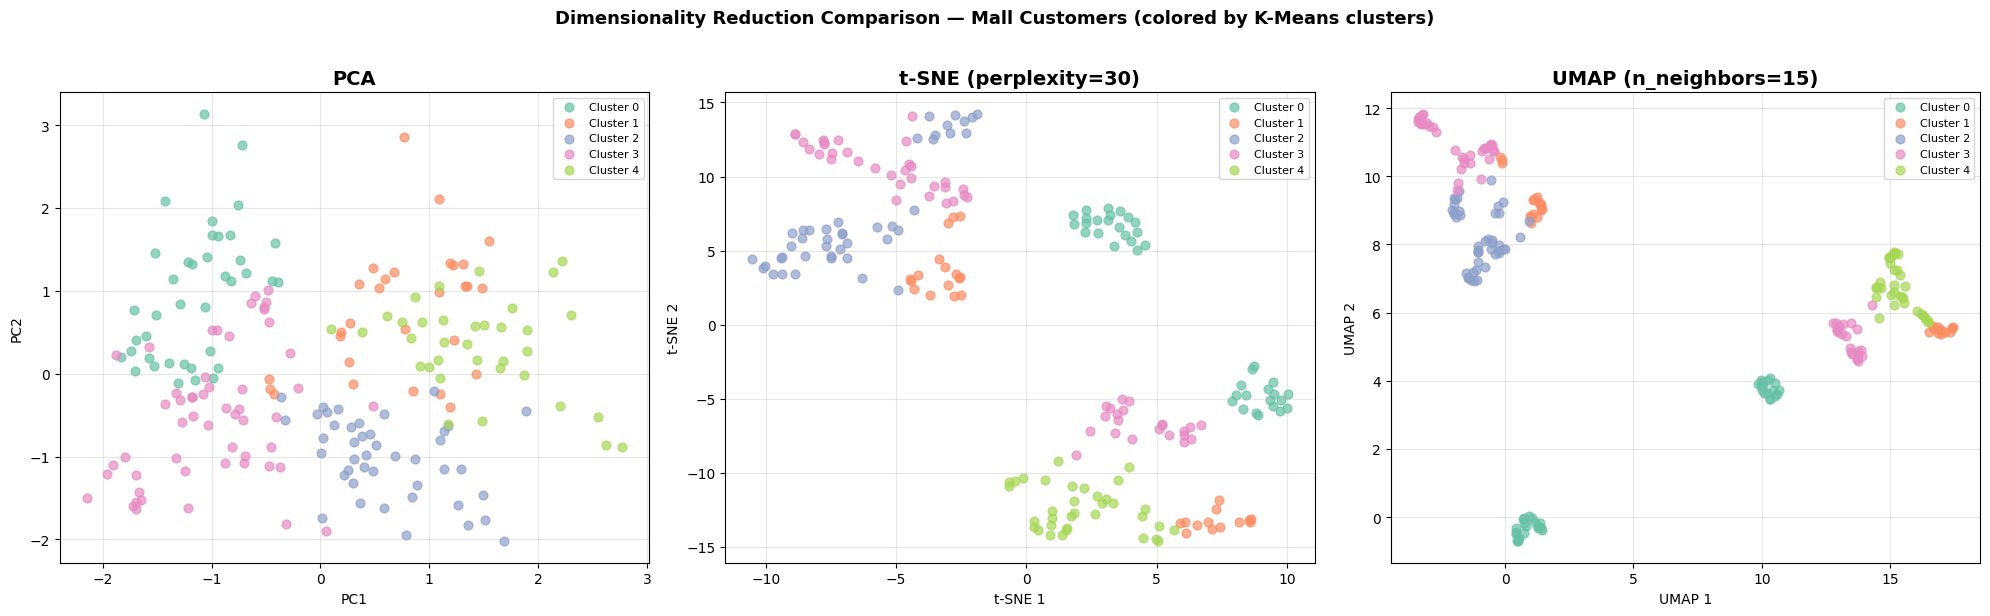

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # Initialize a multi-panel figure canvas with a 1-row, 3-column subplot configuration and define broad custom dimensions in inches
palette = sns.color_palette('Set2', 5)  # Generate a discrete categorical color palette containing 5 distinct hues from the Seaborn 'Set2' color scheme to map to individual clusters

# PCA
for c in range(5):  # Loop sequentially through each of the 5 distinct K-Means cluster IDs to isolate and plot data points belonging to the current group
    mask = cluster_labels == c  # Generate a boolean indexing mask to extract the multi-dimensional slice corresponding exclusively to the current cluster index
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=40)  # Render a 2D scatter plot of the current cluster's points in PCA space with assigned group coloring, partial opacity, and custom point sizing
axes[0].set_title('PCA', fontsize=14, fontweight='bold')  # Set a prominent, bold descriptive title for the first panel to label it as the PCA dimensionality reduction plot
axes[0].set_xlabel('PC1')  # Set the descriptive label for the horizontal axis of the first subplot to represent the first principal component
axes[0].set_ylabel('PC2')  # Set the descriptive label for the vertical axis of the first subplot to represent the second principal component
axes[0].legend(fontsize=8)  # Display the categorical color legend in the first panel using a compressed font size for compact spatial organization
axes[0].grid(True, alpha=0.3)  # Superimpose a subtle background grid with controlled opacity onto the first subplot to assist in geometric point estimation

# t-SNE
for c in range(5):  # Loop sequentially through each of the 5 distinct K-Means cluster IDs to isolate and plot data points in the t-SNE embedding space
    mask = cluster_labels == c  # Generate a boolean indexing mask to extract the low-dimensional t-SNE coordinates corresponding exclusively to the current cluster index
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=40)  # Render a 2D scatter plot of the current cluster's points in t-SNE space using matching group coloring and transparency profiles
axes[1].set_title('t-SNE (perplexity=30)', fontsize=14, fontweight='bold')  # Set a prominent, bold descriptive title for the second panel indicating the manifold algorithm and its active perplexity configuration
axes[1].set_xlabel('t-SNE 1')  # Set the descriptive label for the horizontal axis of the second subplot to represent the first t-SNE coordinate
axes[1].set_ylabel('t-SNE 2')  # Set the descriptive label for the vertical axis of the second subplot to represent the second t-SNE coordinate
axes[1].legend(fontsize=8)  # Display the categorical color legend in the second panel to maintain consistency across the visual comparison matrix
axes[1].grid(True, alpha=0.3)  # Superimpose a subtle background grid with controlled opacity onto the second subplot to aid coordinate reading

# UMAP
for c in range(5):  # Loop sequentially through each of the 5 distinct K-Means cluster IDs to isolate and plot data points in the UMAP embedding space
    mask = cluster_labels == c  # Generate a boolean indexing mask to extract the low-dimensional UMAP coordinates corresponding exclusively to the current cluster index
    axes[2].scatter(X_umap[mask, 0], X_umap[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=40)  # Render a 2D scatter plot of the current cluster's points in UMAP space using matching group coloring and transparency profiles
axes[2].set_title('UMAP (n_neighbors=15)', fontsize=14, fontweight='bold')  # Set a prominent, bold descriptive title for the third panel indicating the UMAP algorithm and its active neighbor graph configuration
axes[2].set_xlabel('UMAP 1')  # Set the descriptive label for the horizontal axis of the third subplot to represent the first UMAP coordinate
axes[2].set_ylabel('UMAP 2')  # Set the descriptive label for the vertical axis of the third subplot to represent the second UMAP coordinate
axes[2].legend(fontsize=8)  # Display the categorical color legend in the third panel to finish the sub-plot documentation layout
axes[2].grid(True, alpha=0.3)  # Superimpose a subtle background grid with controlled opacity onto the third subplot to assist in cluster proximity estimation

plt.suptitle('Dimensionality Reduction Comparison — Mall Customers (colored by K-Means clusters)',
             fontsize=13, fontweight='bold', y=1.02)  # Establish an overarching global figure title centered above all subplots with controlled scale and a slight height offset to avoid overlapping panel titles
plt.tight_layout()  # Automatically recalculate subplot margins, bounding boxes, and internal text parameters to prevent overlap or clipping across the three panels
plt.show()  # Render the complete three-panel dimensionality reduction comparison figure onto the screen for visual cluster structure audit

### Quick Reference: PCA vs t-SNE vs UMAP

| Method | Type | Preserves | Speed | Axes Interpretable? |
|--------|------|-----------|-------|--------------------|
| PCA | Linear | Global variance | Fast | Yes (loadings) |
| t-SNE | Non-linear | Local neighborhoods | Slow | No |
| UMAP | Non-linear | Local + global structure | Medium | No |

## 7. TODO: Which Visualization Best Reveals Cluster Structure?

Look at the 3 plots above and answer:

1. Which method produces the most visually separated clusters?
2. Why does PCA sometimes fail to separate clusters that t-SNE/UMAP can?
3. Would you use t-SNE or UMAP for a dataset with 1 million rows? Why?
4. Why should you NOT interpret distances in t-SNE plots the same way as in PCA plots?

**TODO: Your answer here**

1.  **Which method produces the most visually separated clusters?**
    UMAP generally produces the most visually separated and distinct clusters in the provided plots, followed by t-SNE. PCA's clusters appear much more overlapping.

2.  **Why does PCA sometimes fail to separate clusters that t-SNE/UMAP can?**
    PCA is a linear dimensionality reduction technique that seeks to maximize variance along new orthogonal axes. It is effective at preserving global structure, but it can fail to separate clusters if their underlying relationships in the high-dimensional space are non-linear. t-SNE and UMAP, being non-linear techniques, are better at "unfolding" complex non-linear structures and preserving local neighborhood relationships, which allows them to reveal clusters that are not linearly separable.

3.  **Would you use t-SNE or UMAP for a dataset with 1 million rows? Why?**
    For a dataset with 1 million rows, UMAP would be strongly preferred over t-SNE. UMAP is significantly faster and more scalable than t-SNE. t-SNE's computational complexity scales roughly quadratically (O(N^2) or O(N log N)), making it prohibitively slow for very large datasets, whereas UMAP has better scalability (closer to O(N log N)).

4.  **Why should you NOT interpret distances in t-SNE plots the same way as in PCA plots?**
    *   **PCA Plots:** Distances in PCA plots are meaningful representations of Euclidean distances in the original (or projected) feature space. Points that are far apart in a PCA plot are truly far apart in the high-dimensional data.
    *   **t-SNE Plots:** Distances in t-SNE plots are not directly interpretable as Euclidean distances. t-SNE prioritizes the preservation of local neighborhood structures, meaning points that are close in high-dimensional space remain close in the 2D embedding. However, to achieve this, it often distorts global distances significantly. The absolute distances between clusters, or the apparent size/density of a cluster in a t-SNE plot, may not accurately reflect the original high-dimensional relationships. UMAP attempts to preserve both local and global structure better than t-SNE, but still, direct distance interpretation should be approached with caution.

---
## Summary

| Concept | Details |
|---------|--------|
| PCA | Linear projection onto max-variance directions. Fast, interpretable, but misses non-linear structure |
| t-SNE | Preserves local neighborhoods via probability distributions. Good for visualization, slow on large data |
| UMAP | Topological approach — preserves local AND global structure. Faster than t-SNE, scales better |
| perplexity (t-SNE) | Controls neighborhood size. Typical range: 5-50 |
| n_neighbors (UMAP) | Controls local vs global balance. Low = local detail, high = global structure |
| Key rule | t-SNE/UMAP are for visualization only — do not use the 2D output for clustering or modeling |